## 1. Imports and Helper Functions

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import loadmat  # For loading .mat files
from scipy.stats import kurtosis

# Set plotting style
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

# Data directory
DATA_DIR = "data"

In [3]:
def list_sample_files():
    """
    List all .mat sample files in the data directory.
    
    Returns:
    --------
    files : list of str
        Sorted list of .mat sample filenames
    """
    return sorted([f for f in os.listdir(DATA_DIR) if f.endswith("_sample.mat")])


def load_sample(file_name):
    """
    Load a sample .mat file.
    
    Parameters:
    -----------
    file_name : str
        Name of the .mat file (e.g., 'H_353rpm_sample.mat')
    
    Returns:
    --------
    data : dict
        Contains keys: time_acc, acc_m_s2, acc_g, fs_acc, time_rpm, rpm, 
                      fs_rpm, mean_rpm, condition, rpm_nominal
    """
    path = os.path.join(DATA_DIR, file_name)
    
    # Load MATLAB format
    mat_data = loadmat(path)
    
    # Extract data (loadmat adds metadata keys starting with '__')
    data = {k: v for k, v in mat_data.items() if not k.startswith('__')}
    
    # Flatten scalar values for easier use
    for key in ['fs_acc', 'fs_rpm', 'mean_rpm', 'rpm_nominal']:
        if key in data and hasattr(data[key], 'flatten'):
            data[key] = float(data[key].flatten()[0])
    
    # Flatten time and signal arrays (remove extra dimensions)
    for key in ['time_acc', 'acc_m_s2', 'acc_g', 'time_rpm', 'rpm']:
        if key in data and hasattr(data[key], 'flatten'):
            data[key] = data[key].flatten()
    
    # Convert condition to string
    if 'condition' in data:
        if hasattr(data['condition'], '__iter__') and not isinstance(data['condition'], str):
            data['condition'] = str(data['condition'][0]) if len(data['condition']) > 0 else ''
        else:
            data['condition'] = str(data['condition'])
    
    return data

In [4]:
def compute_spectrum(signal_data, fs, window=True):
    """
    Compute single-sided amplitude spectrum.
    
    Parameters:
    -----------
    signal_data : ndarray
        Time-domain signal
    fs : float
        Sampling frequency in Hz
    window : bool
        If True, apply Hanning window before FFT (default: True)
    
    Returns:
    --------
    freq : ndarray
        Frequency vector (positive frequencies only)
    amplitude : ndarray
        Single-sided amplitude spectrum
    """
    N = len(signal_data)
    
    # Apply window to reduce spectral leakage
    if window:
        win = np.hanning(N)
        signal_windowed = signal_data * win
        # Compensate for window amplitude loss
        window_correction = 2.0 / np.sum(win)  # = 2/(N*mean(win)), standard single-sided amplitude correction
    else:
        signal_windowed = signal_data
        window_correction = 2.0 / N
    
    # Compute FFT
    fft_vals = np.fft.fft(signal_windowed)
    
    # Single-sided spectrum (positive frequencies only)
    # Don't double DC component (index 0) and Nyquist (if N is even)
    freq = np.fft.fftfreq(N, 1/fs)[:N//2]
    amplitude = np.abs(fft_vals[:N//2]) * window_correction
    amplitude[0] /= 2  # DC component should not be doubled
    if N % 2 == 0:
        amplitude[-1] /= 2  # Nyquist component should not be doubled (if N is even)
    
    return freq, amplitude


def simple_time_features(signal_data):
    """
    Compute simple time-domain features.
    
    Parameters:
    -----------
    signal_data : ndarray
        Time-domain signal
    
    Returns:
    --------
    features : dict
        Dictionary containing RMS, peak, and kurtosis
    """
    rms = np.sqrt(np.mean(signal_data**2))
    peak = np.max(np.abs(signal_data))
    # Use fisher=False for kurtosis (Normal distribution = 3)
    kurt = kurtosis(signal_data, fisher=False)
    
    return {
        'RMS': rms,
        'Peak': peak,
        'Kurtosis': kurt
    }


def envelope_spectrum(signal_data, fs, bandpass=None):
    """
    Compute envelope spectrum using Hilbert transform.
    
    Parameters:
    -----------
    signal_data : ndarray
        Time-domain signal
    fs : float
        Sampling frequency in Hz
    bandpass : tuple or None
        If tuple (low_freq, high_freq), apply band-pass filter before envelope.
        If None, no filtering is applied.
    
    Returns:
    --------
    freq : ndarray
        Frequency vector for envelope spectrum
    env_spectrum : ndarray
        Envelope spectrum amplitude
    envelope : ndarray
        Envelope time series
    filtered_signal : ndarray
        Band-pass filtered signal (or original if bandpass=None)
    """
    # Apply band-pass filter if requested
    if bandpass is not None:
        low_freq, high_freq = bandpass
        sos = signal.butter(4, [low_freq, high_freq], btype='bandpass', fs=fs, output='sos')
        filtered_signal = signal.sosfilt(sos, signal_data)
    else:
        filtered_signal = signal_data
    
    # Compute analytic signal using Hilbert transform
    analytic_signal = signal.hilbert(filtered_signal)
    
    # Envelope is the magnitude of the analytic signal
    envelope = np.abs(analytic_signal)
    
    # Compute spectrum of the envelope
    freq, env_spectrum = compute_spectrum(envelope, fs)
    
    return freq, env_spectrum, envelope, filtered_signal

In [ ]:
# Bearing Geometry and Fault Characteristic Frequencies
# These values are specific to the bearing type used in the experiment

# Bearing fault characteristic frequencies (orders relative to shaft speed)
# These are cycles per revolution - multiply by shaft frequency (Hz) to get fault frequency

BPFI = 10.824  # Ball Pass Frequency Inner race (cycles per revolution)
BPFO = 8.176   # Ball Pass Frequency Outer race (cycles per revolution)
BSF = 3.464    # Ball Spin Frequency (cycles per revolution)
FTF = 0.414    # Fundamental Train Frequency (cage rotation, cycles per revolution)

# Physical Interpretation:
# 
# BPFI: How many times per shaft revolution do rolling elements pass over a point on the INNER race
#       Higher than BPFO because inner race rotates with shaft (relative motion is faster)
#
# BPFO: How many times per shaft revolution do rolling elements pass over a point on the OUTER race  
#       Lower than BPFI because outer race is stationary
#
# BSF: How fast each rolling element (ball) rotates on its own axis
#      Fault on a ball creates 2 impacts per rotation → actual fault freq = 2×BSF
#
# FTF: How fast the cage (which holds the rolling elements) rotates
#      Rarely used for fault diagnosis but important for understanding bearing kinematics

def calculate_fault_frequency(rpm, fault_order):
    """
    Calculate fault frequency in Hz from RPM and fault order.
    
    Parameters:
    -----------
    rpm : float
        Shaft rotational speed in RPM (use measured mean RPM for accuracy)
    fault_order : float
        Fault characteristic order (BPFI, BPFO, BSF, or FTF)
    
    Returns:
    --------
    freq_hz : float
        Fault frequency in Hz
    
    Theory:
    -------
    Fault frequency = (Fault Order) × (Shaft Frequency)
    where Shaft Frequency [Hz] = RPM / 60
    
    Example:
    At mean RPM ≈ 855 (nominal 877), shaft frequency = 855/60 = 14.25 Hz
    BPFI fault frequency = 10.824 × 14.25 = 154.2 Hz
    """
    shaft_freq_hz = rpm / 60.0
    fault_freq_hz = fault_order * shaft_freq_hz
    return fault_freq_hz


def add_rpm_harmonics(ax, rpm, max_freq=2000, n_harmonics=1, color='gray', alpha=0.3, label_prefix=''):
    """
    Add vertical line for shaft speed (1×RPM) to a spectrum plot.
    
    This marks the fundamental rotational frequency, which is useful as a reference
    but should NOT be confused with bearing fault frequencies (which are much higher).
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to plot on
    rpm : float
        Rotational speed in RPM (use measured mean RPM for accuracy)
    max_freq : float
        Maximum frequency to plot harmonics up to
    n_harmonics : int
        Number of harmonics to show (default 3: shows 1×, 2×, 3×RPM)
    color : str
        Color of the harmonic line
    alpha : float
        Transparency of the line
    label_prefix : str
        Prefix for labels (e.g., 'H: ' for healthy)
    """
    freq_hz = rpm / 60.0  # Convert RPM to Hz (shaft frequency)
    
    # Show only the fundamental (1×RPM) as a clear reference
    if freq_hz <= max_freq:
        ax.axvline(freq_hz, color=color, linestyle='--', linewidth=1.0, alpha=alpha+0.2)
        ax.text(freq_hz, ax.get_ylim()[1] * 0.95, f'{label_prefix}1×RPM\n({freq_hz:.1f} Hz)', 
               rotation=90, va='top', ha='right', fontsize=8, alpha=0.7)


def add_bearing_fault_frequencies(ax, rpm, fault_type, max_freq=2000, color='red', alpha=0.5, n_harmonics=3):
    """
    Add vertical lines for bearing fault characteristic frequencies.
    
    Bearing faults create periodic impacts that appear as distinct peaks in the envelope spectrum.
    This function marks the expected frequencies based on bearing geometry and rotational speed.
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to plot on
    rpm : float
        Rotational speed in RPM (use measured mean RPM for accuracy)
    fault_type : str
        Type of fault: 'IR' (inner race), 'OR' (outer race), or 'Roller'
    max_freq : float
        Maximum frequency to plot up to
    color : str
        Color of the fault frequency lines
    alpha : float
        Transparency of the lines
    n_harmonics : int
        Number of harmonics to show (default 3: fundamental + 2 harmonics)
    
    Theory:
    -------
    Each fault type has a characteristic frequency based on bearing geometry:
    
    Inner Race (IR): fault_freq = BPFI × (RPM/60)
        - Inner race rotates with shaft
        - Rolling elements pass over fault more frequently
        - Typically 8-12 times per revolution for common bearings
    
    Outer Race (OR): fault_freq = BPFO × (RPM/60)  
        - Outer race is stationary
        - Lower frequency than inner race
        - Typically 6-10 times per revolution
    
    Roller/Ball: fault_freq = 2×BSF × (RPM/60)
        - Factor of 2 because defect hits twice per ball rotation
        - Typically 4-7 times per revolution
        - Lowest of the three fault frequencies
    """
    freq_hz = rpm / 60.0  # Shaft frequency in Hz
    
    if fault_type == 'IR':
        # Inner race fault: BPFI × shaft speed (Hz)
        fault_order = BPFI
        label = 'BPFI'
    elif fault_type == 'OR':
        # Outer race fault: BPFO × shaft speed (Hz)
        fault_order = BPFO
        label = 'BPFO'
    elif fault_type == 'Roller':
        # Rolling element fault: 2×BSF × shaft speed (Hz)
        # (factor of 2 because each defect hits twice per revolution)
        fault_order = 2 * BSF
        label = '2×BSF'
    else:
        return
    
    fault_freq = fault_order * freq_hz  # Actual fault frequency in Hz
    
    # Plot fundamental and up to n_harmonics
    for i in range(1, n_harmonics + 1):
        f = i * fault_freq
        if f <= max_freq:
            ax.axvline(f, color=color, linestyle=':', linewidth=1.2, alpha=alpha)
            if i == 1:
                ax.text(f, ax.get_ylim()[1] * 0.88, f'{label}\n({f:.1f} Hz)', 
                       rotation=90, va='top', ha='right', fontsize=8, color=color, weight='bold')
            else:
                ax.text(f, ax.get_ylim()[1] * 0.88, f'{i}×{label}', 
                       rotation=90, va='top', ha='right', fontsize=7, color=color, alpha=0.7)

---

## 2. Explore Available Samples

In [6]:
# List all sample files
sample_files = list_sample_files()

print(f"Found {len(sample_files)} sample files:")
print()

# Parse and display in a table
file_info = []
for fname in sample_files:
    data = load_sample(fname)
    n_samples = len(data['time_acc'])
    fs = float(data['fs_acc'])
    duration_corrected = (n_samples) / fs  # Correct duration
    
    file_info.append({
        'File': fname,
        'Condition': str(data['condition']),
        'Nominal RPM': int(data['rpm_nominal']),
        'Mean RPM': float(data['mean_rpm']),
        'Sampling Freq (Hz)': fs,
        'Duration (s)': duration_corrected
    })

df_files = pd.DataFrame(file_info)
df_files

Found 8 sample files:



,File,Condition,Nominal RPM,Mean RPM,Sampling Freq (Hz),Duration (s)
0,H_353rpm_sample.mat,H,353,338.789890,20480.0,2.0
1,H_877rpm_sample.mat,H,877,858.488691,20480.0,2.0
2,IR_353rpm_sample.mat,IR,353,335.769964,20480.0,2.0
3,IR_877rpm_sample.mat,IR,877,854.887580,20480.0,2.0
4,OR_353rpm_sample.mat,OR,353,340.073907,20480.0,2.0
5,OR_877rpm_sample.mat,OR,877,858.940172,20480.0,2.0
6,Roller_353rpm_sample.mat,Roller,353,338.803865,20480.0,2.0
7,Roller_877rpm_sample.mat,Roller,877,858.124634,20480.0,2.0


### Experimental Setup

The data were acquired from a custom bearing test rig designed for controlled fault injection studies. The test rig features:

- **Radial and axial load control** for realistic operating conditions
- **Variable speed motor** for testing at different rotational speeds
- **High-frequency accelerometers** (20.48 kHz sampling) for vibration measurement
- **Precisely manufactured faults** on bearing components (inner race, outer race, rolling elements)

<div align="center">

| Test Rig Overview | Internal Configuration | Applied Loads |
|:-----------------:|:----------------------:|:-------------:|
| <img src="images/TestRig.jpg" width="250"/> | <img src="images/TestRigInside_cut.png" width="250"/> | <img src="images/TestRigLoads_.jpg" width="250"/> |

**Figure:** (Left) Complete test rig assembly. (Center) Internal view showing bearing housing and load application mechanism. (Right) Schematic of radial and axial load configuration.

</div>

<div align="center">
<img src="images/bearing_lateral.JPEG" width="400"/>

**Figure:** Lateral view of the test bearing showing the measurement location and load direction.
</div>

<div align="center">
<img src="images/damages.png" width="500"/>

**Figure:** Manufactured bearing faults used in the experiments. The inner race (IR) and outer race (OR) faults are precisely milled slots with dimensions **2 mm × 0.5 mm** (diameter × depth), creating controlled localized defects that simulate real-world bearing damage. Source: [Giraudo et al., 2025](https://www.mdpi.com/1424-8220/25/8/2419)
</div>

**Test Conditions:**
- Radial load: 124.8 kN
- Axial load: 0 kN
- Operating speeds: 353 rpm and 877 rpm
- Bearing type: Spherical roller bearing (reference geometry in Section 5)

---

---

## 3. Load Example Pair: Healthy vs Inner Race Fault

Let's compare a **healthy bearing** with an **inner race fault** at **877 rpm**.

In [7]:
# Load healthy sample at 877 rpm
data_h = load_sample('H_877rpm_sample.mat')

# Load inner race fault at 877 rpm
data_ir = load_sample('IR_877rpm_sample.mat')

print("Healthy bearing (877 rpm):")
print(f"  Condition: {data_h['condition']}")
print(f"  Sampling frequency: {data_h['fs_acc']:.1f} Hz")
print(f"  Mean RPM: {data_h['mean_rpm']:.1f}")
print(f"  Duration: {data_h['time_acc'][-1]:.2f} s")
print(f"  Number of samples: {len(data_h['acc_m_s2'])}")
print()

print("Inner race fault (877 rpm):")
print(f"  Condition: {data_ir['condition']}")
print(f"  Sampling frequency: {data_ir['fs_acc']:.1f} Hz")
print(f"  Mean RPM: {data_ir['mean_rpm']:.1f}")
print(f"  Duration: {data_ir['time_acc'][-1]:.2f} s")
print(f"  Number of samples: {len(data_ir['acc_m_s2'])}")

Healthy bearing (877 rpm):
  Condition: H
  Sampling frequency: 20480.0 Hz
  Mean RPM: 858.5
  Duration: 2.00 s
  Number of samples: 40960

Inner race fault (877 rpm):
  Condition: IR
  Sampling frequency: 20480.0 Hz
  Mean RPM: 854.9
  Duration: 2.00 s
  Number of samples: 40960


---

## 4. Time-Domain Visualization and Kurtosis

### What is Kurtosis?

**Kurtosis** is a statistical measure of the "tailedness" of a probability distribution. In vibration analysis:

- **Low kurtosis** (≈ 3 for Gaussian noise): Smooth, random vibration
- **High kurtosis** (>> 3): Signal with sharp, impulsive events (typical of bearing faults)

When a bearing has a localized fault (crack, spall), the rolling elements hit the damaged area, creating periodic **impulses**. These impulses increase the kurtosis of the vibration signal.

Let's visualize the acceleration signals and compute their time-domain features.

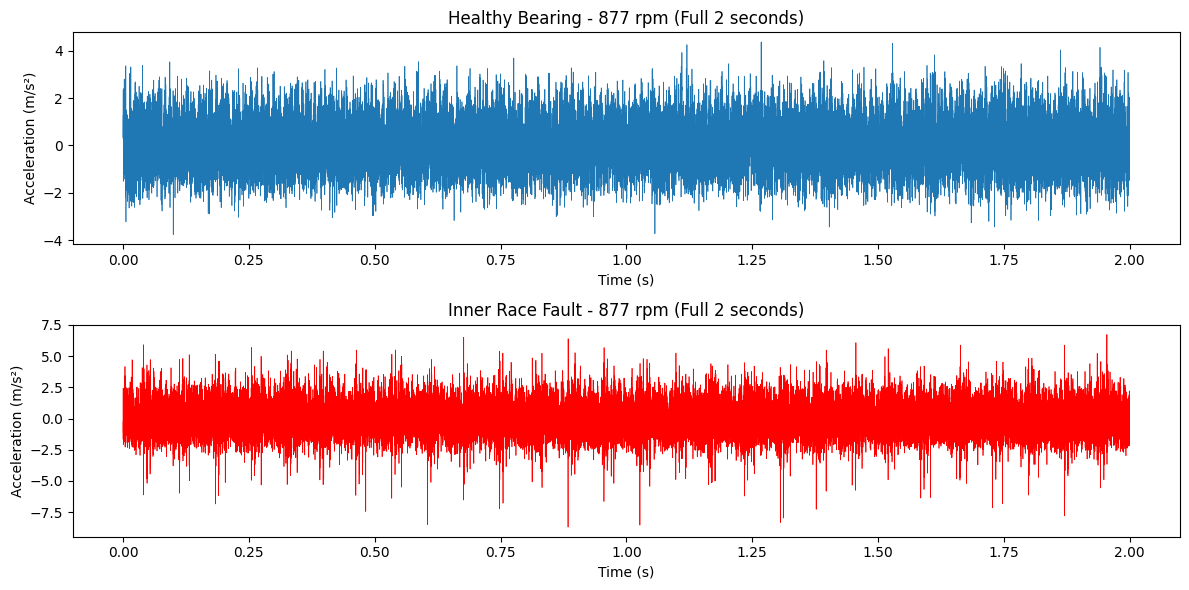

In [8]:
# Plot full 2-second signals
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Healthy
axes[0].plot(data_h['time_acc'], data_h['acc_m_s2'], linewidth=0.5)
axes[0].set_title(f"Healthy Bearing - 877 rpm (Full 2 seconds)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Acceleration (m/s²)")

# Inner race fault
axes[1].plot(data_ir['time_acc'], data_ir['acc_m_s2'], linewidth=0.5, color='red')
axes[1].set_title(f"Inner Race Fault - 877 rpm (Full 2 seconds)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Acceleration (m/s²)")

plt.tight_layout()
plt.show()

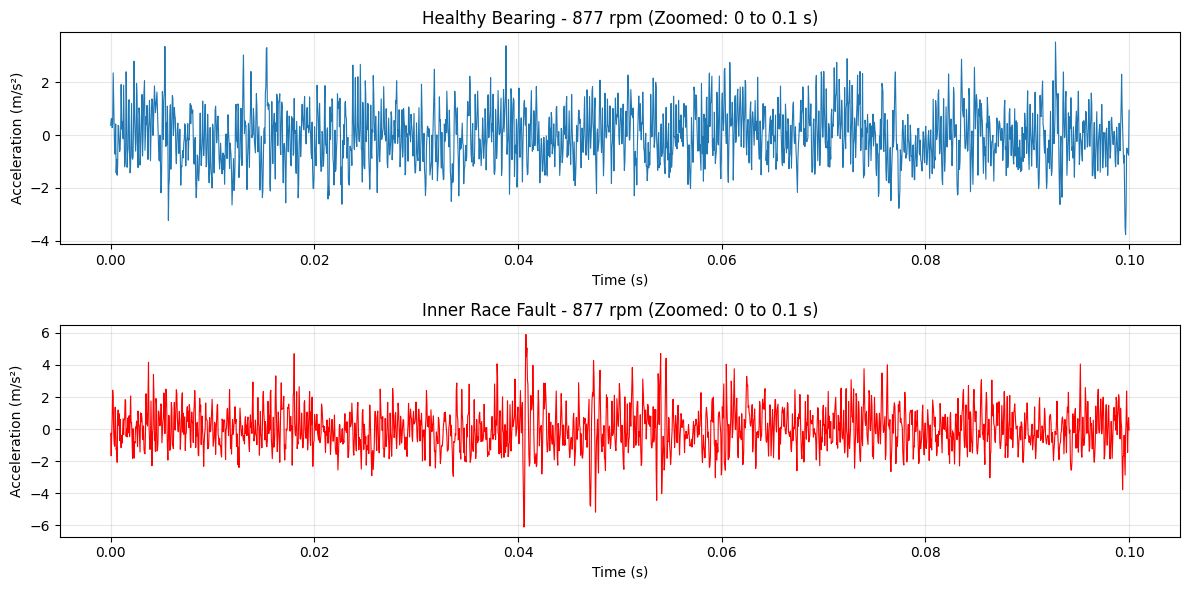

In [9]:
# Zoom into a short window (0.1 seconds) to see details
zoom_duration = 0.1  # seconds

# Find indices for zoom
idx_h = np.where(data_h['time_acc'] <= zoom_duration)[0]
idx_ir = np.where(data_ir['time_acc'] <= zoom_duration)[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Healthy (zoomed)
axes[0].plot(data_h['time_acc'][idx_h], data_h['acc_m_s2'][idx_h], linewidth=0.8)
axes[0].set_title(f"Healthy Bearing - 877 rpm (Zoomed: 0 to {zoom_duration} s)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Acceleration (m/s²)")
axes[0].grid(True, alpha=0.3)

# Inner race fault (zoomed)
axes[1].plot(data_ir['time_acc'][idx_ir], data_ir['acc_m_s2'][idx_ir], linewidth=0.8, color='red')
axes[1].set_title(f"Inner Race Fault - 877 rpm (Zoomed: 0 to {zoom_duration} s)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Acceleration (m/s²)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Compute time-domain features
features_h = simple_time_features(data_h['acc_m_s2'])
features_ir = simple_time_features(data_ir['acc_m_s2'])

# Create comparison table
df_features = pd.DataFrame({
    'Healthy': features_h,
    'Inner Race Fault': features_ir
})

print("Time-Domain Features Comparison:")
print()
df_features

Time-Domain Features Comparison:



,Healthy,Inner Race Fault
RMS,0.995269,1.334172
Peak,4.370522,8.691693
Kurtosis,2.942898,4.261582


**Observation**: The inner race fault typically shows **higher kurtosis** than the healthy bearing due to the presence of impulsive events when the rolling elements strike the damaged area.

---

## 5. Bearing Geometry and Characteristic Fault Frequencies

### Understanding Bearing Kinematics

Before analyzing frequency spectra, it's crucial to understand **why** bearing faults create periodic vibrations at specific frequencies. This is not a random phenomenon and it's determined by the bearing's **geometry** and **kinematics**.

#### The Physics of Rolling Element Bearings

A rolling element bearing consists of:
- **Inner race** (rotates with the shaft)
- **Outer race** (typically stationary, mounted in the housing)
- **Rolling elements** (balls or rollers, held in a cage)
- **Cage** (keeps rolling elements evenly spaced)

<div style="background-color:#f0f8ff; padding:15px; border-left:4px solid #2196F3; margin:10px 0;">

**Key Insight:** When a fault (crack, spall, pit) exists on any of these components, it creates a **periodic impact** every time a rolling element passes over it. The frequency of these impacts depends on:

1. **Shaft rotational speed** (RPM)
2. **Number of rolling elements** (Z)
3. **Bearing geometry** (pitch diameter D, ball diameter d, contact angle α)

</div>

<div align="center">
<img src="images/Impact_bearing.jpg" width="500"/>

**Figure:** Impact mechanism when a rolling element passes over a fault. Source: [Kim et al., 2020](https://www.mdpi.com/2076-3417/10/20/7302)
</div>

#### Characteristic Fault Frequencies

For the bearing used in this dataset, the fault orders (cycles per shaft revolution) are:

<div align="center">

| Test Bearing Model | Bearing Geometry Parameters |
|:------------------:|:---------------------------:|
| <img src="images/SKFCCKW33.png" width="400"/> | <img src="images/SKF_drawing.png" width="400"/> |

**Figure:** (Left) SKF 22240 CC/W33 spherical roller bearing employed in our dataset. (Right) Bearing geometry. Source: [Giraudo et al., 2025](https://www.mdpi.com/1424-8220/25/8/2419)

</div>

---

**Fault Orders (cycles per shaft revolution):**

| Fault Type | Order | Physical Meaning |
|-----------|-------|-----------------|
| **BPFI** (Ball Pass Frequency Inner) | 10.824 | Number of times rolling elements pass over a point on the inner race per shaft revolution |
| **BPFO** (Ball Pass Frequency Outer) | 8.176 | Number of times rolling elements pass over a point on the outer race per shaft revolution |
| **BSF** (Ball Spin Frequency) | 3.464 | How fast each rolling element rotates on its own axis |
| **FTF** (Fundamental Train Frequency) | 0.414 | Cage rotation frequency |

**Note:** For roller/ball faults, the actual fault frequency is **2×BSF** because each defect on a ball creates **two impacts per ball rotation** (one when entering the load zone, one when exiting).

---

### Why BPFI > BPFO?

Notice that **BPFI is higher than BPFO**.

- The **inner race rotates with the shaft** → high relative velocity between balls and inner race
- The **outer race is stationary** → lower relative velocity between balls and outer race
- Therefore, rolling elements pass over an inner race defect **more frequently** than an outer race defect

---

### Converting Orders to Frequencies

Given a shaft speed, we can convert these **orders** (dimensionless) to **frequencies** (Hz):

$$
f_{\text{fault}} = \text{Order} \times f_{\text{shaft}}
$$

where:
- $f_{\text{shaft}} = \text{RPM} / 60$ (shaft frequency in Hz)

**Important:** The nominal test speed is 877 RPM, but the actual measured mean speed (from the tachometer) is approximately **855–859 RPM** depending on the test condition. All analysis in this notebook uses the **measured mean RPM** for accurate frequency estimation.

As an example, for a mean speed of **≈ 858 RPM** (healthy bearing at nominal 877 RPM):
- Shaft frequency: $f_s \approx 858/60 = 14.3$ Hz

| Fault Type | Frequency Calculation | **Frequency (Hz)** |
|-----------|---------------------|-------------------|
| **BPFI** | $10.824 \times 14.3$ | **≈ 154.8 Hz** |
| **BPFO** | $8.176 \times 14.3$ | **≈ 116.9 Hz** |
| **2×BSF** | $2 \times 3.464 \times 14.3$ | **≈ 99.1 Hz** |
| **FTF** | $0.414 \times 14.3$ | **≈ 5.9 Hz** |

---

### Summary: Why This Matters

✅ **Before looking at any spectrum**, we now know (approximately):
- An inner race fault should produce **≈ 155 Hz** and harmonics (2×, 3×, ...)
- An outer race fault should produce **≈ 117 Hz** and harmonics
- A roller fault should produce **≈ 99 Hz** and harmonics

✅ **These are NOT random peaks** — they are physically determined by bearing geometry and shaft speed.

✅ **Now let's see these frequencies in action!** In the next sections, we'll analyze real data and observe:
- How standard FFT struggles to detect these frequencies (Section 6)
- How envelope analysis reveals them clearly (Section 7)

---

---

## 6. Standard FFT Analysis

Now that we know **what frequencies to expect** from the bearing geometry (Section 5), let's compute the **FFT** of the raw acceleration signals to see if we can detect them.

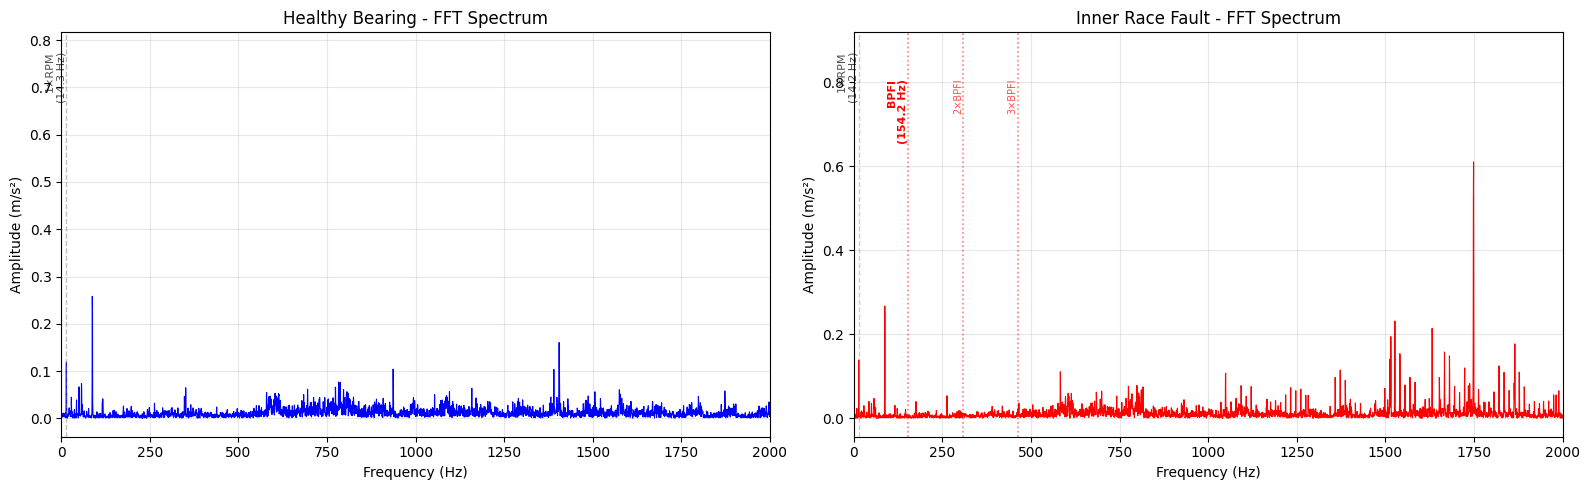

In [11]:
# Compute spectra
freq_h, amp_h = compute_spectrum(data_h['acc_m_s2'], data_h['fs_acc'])
freq_ir, amp_ir = compute_spectrum(data_ir['acc_m_s2'], data_ir['fs_acc'])

# Plot side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy
axes[0].plot(freq_h, amp_h, linewidth=0.8, color='blue')
axes[0].set_xlim(0, 2000)
add_rpm_harmonics(axes[0], data_h['mean_rpm'], max_freq=200)
axes[0].set_title("Healthy Bearing - FFT Spectrum")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Amplitude (m/s²)")
axes[0].grid(True, alpha=0.3)

# Inner race fault
axes[1].plot(freq_ir, amp_ir, linewidth=0.8, color='red')
axes[1].set_xlim(0, 2000)
add_rpm_harmonics(axes[1], data_ir['mean_rpm'], max_freq=2000, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_ir['mean_rpm'], 'IR', max_freq=2000)
axes[1].set_title("Inner Race Fault - FFT Spectrum")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude (m/s²)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation**: 

Now that we know the theoretical fault frequencies from Section 5, we can evaluate the FFT:

- The **red dotted lines** mark where we expect fault peaks (BPFI ≈ 154 Hz, based on measured mean RPM)
- In the **FFT spectrum**, it's difficult to identify clear fault signatures because:
  - The fault energy is spread across many frequencies
  - Background noise and structural resonances dominate  
  - Fault-related impulses are buried in the spectrum

**Challenge**: The theoretical frequencies are present, but they're **hard to distinguish** from noise.

This is where **envelope analysis** becomes the solution and it will extract these fault frequencies much more clearly!

---

## 7. Envelope Analysis: The Physics Behind Bearing Fault Detection

### Understanding the Problem: Why Standard FFT Fails

When a bearing develops a fault (crack, spall, or pit) on one of its races, a fascinating physical phenomenon occurs:

**1. The Impact Event** ⚙️  
Every time a rolling element (ball or roller) strikes the defect, it creates a brief mechanical impact.

**2. Structural Resonance Excitation** 🔔  
This impact, though short-lived, excites the **natural resonances** ($f_c$, carrier frequencies) of the machine structure. These resonances are typically at **high frequencies** (hundreds to thousands of Hz).

**3. Periodic Repetition** 🔄  
The impacts repeat at a fixed, **low frequency** ($f_m$, modulating frequency) - the **characteristic fault frequency** (e.g., BPFI for inner race faults).

---

### The Resulting Signal: Amplitude Modulation (AM)

The vibration signal is an **amplitude-modulated (AM) signal**: high-frequency resonances ($f_c$) are "pulsed" or modulated in amplitude by the low-frequency fault repetition ($f_m$).

$$
x(t) = [1 + m \cdot \cos(2\pi f_m t)] \cdot \cos(2\pi f_c t)
$$

where:  
- $f_m$ = fault frequency (modulating, low freq, e.g., BPFI ≈ 155 Hz)  
- $f_c$ = structural resonance (carrier, high freq, e.g., 2000 Hz)  
- $m$ = modulation depth (fault severity)

---

### Why Standard FFT Misses the Fault

In a standard FFT spectrum:

- **Low-frequency energy** is dominated by normal rotational vibrations (unbalance, misalignment) with **much higher amplitude** than fault signals
- The fault frequency $f_m$ is **buried in noise** and cannot be distinguished
- The high-frequency resonance $f_c$ appears, but without revealing the modulation pattern

---

### The Solution: Envelope Analysis (Demodulation)

Envelope analysis acts like a **radio demodulator** for vibrations. It extracts the low-frequency modulation ($f_m$) from the high-frequency carrier ($f_c$).

**Three-Step Process:**

1. **Band-Pass Filtering** 🎛️  
   Isolate the frequency band containing the excited structural resonance ($f_c$)

2. **Envelope Extraction (Hilbert Transform)** 〰️  
   Extract the amplitude modulation pattern (the "shape" of the pulsations)

3. **FFT of Envelope** 📊  
   Compute the spectrum of the envelope → reveals $f_m$ clearly!

---

### What is the Hilbert Transform?

The Hilbert Transform doesn't directly extract the envelope, but creates the **Analytic Signal**:

**Original Signal:** $x(t)$ - the band-passed vibration signal (real-valued)

**Hilbert Transform:** $\hat{x}(t)$ - a version of $x(t)$ with all frequency components phase-shifted by $90°$

**Analytic Signal:** The complex combination

$$
z(t) = x(t) + j \cdot \hat{x}(t)
$$

**Envelope Extraction:** The magnitude (modulus) of the analytic signal

$$
E(t) = |z(t)| = \sqrt{x(t)^2 + \hat{x}(t)^2}
$$

**Physical Meaning:**  
The envelope $E(t)$ represents the **instantaneous amplitude** of the oscillating signal. It captures the pulsations caused by the fault ($f_m$) while removing the high-frequency carrier ($f_c$).

**Envelope Spectrum:**  
Performing FFT on $E(t)$ produces the **envelope spectrum**, which clearly shows peaks at:
- Fault frequency $f_m$ (e.g., BPFI)
- Harmonics: $2f_m$, $3f_m$, ...

---

## 7.1. Understanding Envelope Analysis: Synthetic Signal Example

Before applying envelope analysis to **real bearing data**, let's demonstrate the concept with a **synthetic signal** where we control all parameters. This will help you understand exactly what the Hilbert transform extracts.

### Creating a Controlled AM Signal

We'll create a signal that mimics a faulty bearing:

- A **high-frequency carrier** at 5000 Hz (simulating a structural resonance)
- **Amplitude modulation** at 100 Hz (simulating periodic fault impacts)
- Random **noise** to make it realistic

This controlled experiment will show that envelope analysis successfully extracts the **modulation frequency** (100 Hz) from the **carrier frequency** (5000 Hz).

In [12]:
# Synthetic signal parameters
fs_synth = 25000  # Sampling frequency (Hz)
duration_synth = 1.0  # Duration (s)
t_synth = np.linspace(0, duration_synth, int(fs_synth * duration_synth), endpoint=False)

# High-frequency carrier (e.g., structural resonance at 5 kHz)
f_carrier = 5000  # Hz
carrier = np.sin(2 * np.pi * f_carrier * t_synth)

# Low-frequency amplitude modulation (e.g., fault frequency at 100 Hz)
f_modulation = 100  # Hz
modulation = 0.5 + 0.5 * np.sin(2 * np.pi * f_modulation * t_synth)

# Modulated signal
signal_synth = modulation * carrier

# Add noise
noise_level = 0.1
noise = noise_level * np.random.randn(len(signal_synth))
signal_synth_noisy = signal_synth + noise

print(f"Synthetic signal:")
print(f"  Carrier frequency: {f_carrier} Hz")
print(f"  Modulation frequency: {f_modulation} Hz")
print(f"  Sampling frequency: {fs_synth} Hz")
print(f"  Duration: {duration_synth} s")

Synthetic signal:
  Carrier frequency: 5000 Hz
  Modulation frequency: 100 Hz
  Sampling frequency: 25000 Hz
  Duration: 1.0 s


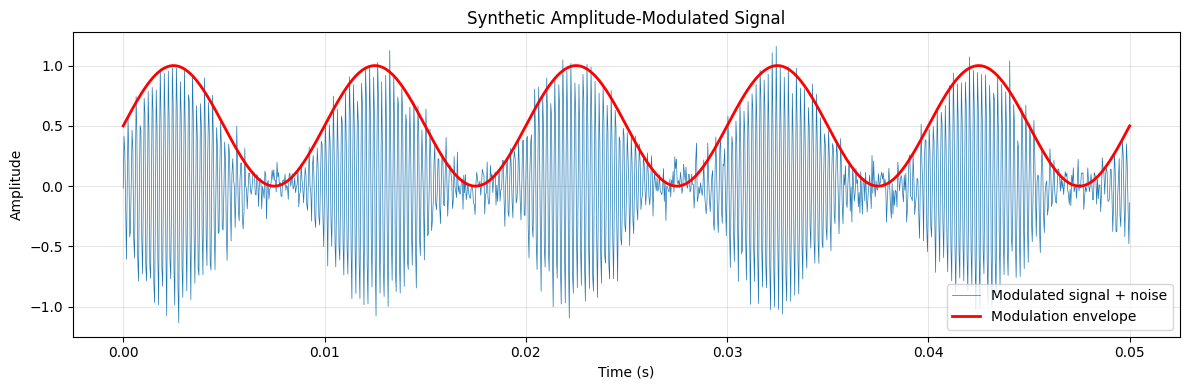

In [13]:
# Plot synthetic signal (short window)
plot_duration = 0.05  # seconds
idx_plot = np.where(t_synth <= plot_duration)[0]

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(t_synth[idx_plot], signal_synth_noisy[idx_plot], linewidth=0.5, label='Modulated signal + noise')
ax.plot(t_synth[idx_plot], modulation[idx_plot], linewidth=2, color='red', label='Modulation envelope')

ax.set_title("Synthetic Amplitude-Modulated Signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

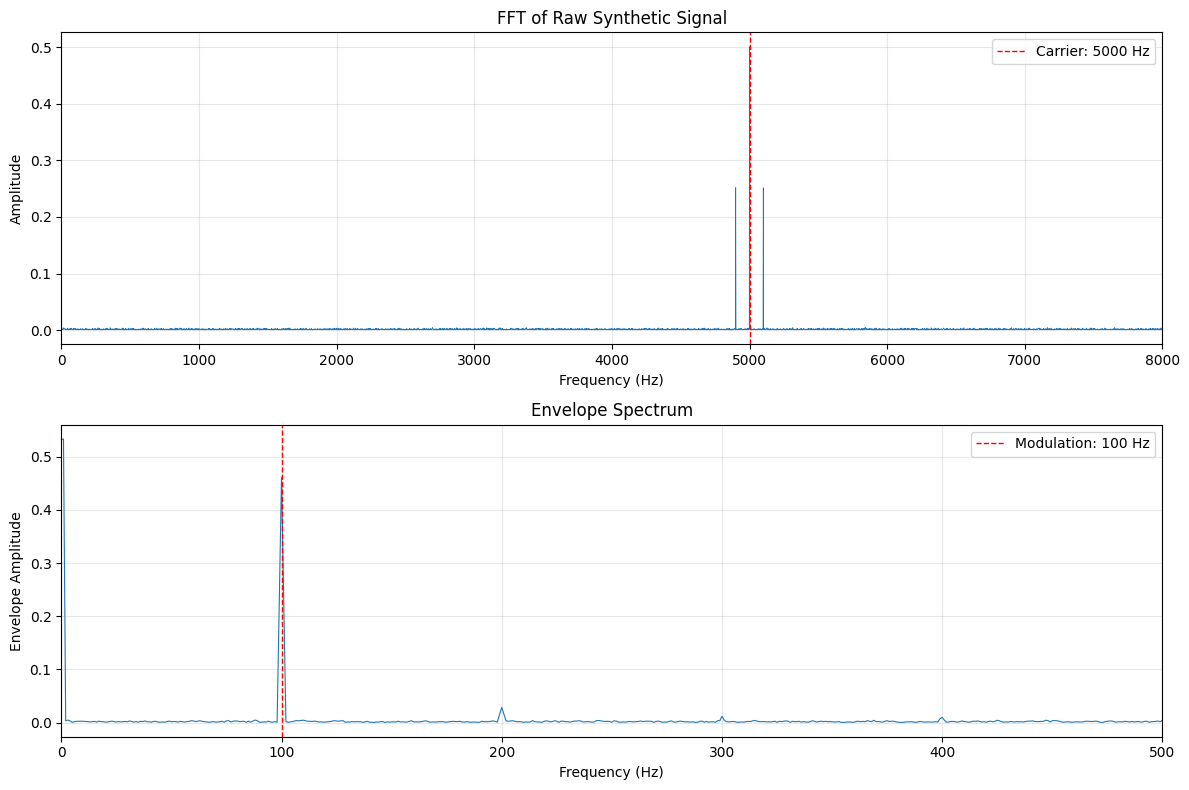

In [14]:
# Compute FFT of raw signal
freq_synth, amp_synth = compute_spectrum(signal_synth_noisy, fs_synth)

# Compute envelope spectrum
freq_env_synth, env_spec_synth, env_synth, _ = envelope_spectrum(
    signal_synth_noisy, fs_synth, bandpass=None
)

# Plot FFT vs Envelope Spectrum
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# FFT of raw signal
axes[0].plot(freq_synth, amp_synth, linewidth=0.5)
axes[0].axvline(f_carrier, color='red', linestyle='--', linewidth=1, label=f'Carrier: {f_carrier} Hz')
axes[0].set_title("FFT of Raw Synthetic Signal")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim([0, 8000])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Envelope spectrum
axes[1].plot(freq_env_synth, env_spec_synth, linewidth=0.8)
axes[1].axvline(f_modulation, color='red', linestyle='--', linewidth=1, label=f'Modulation: {f_modulation} Hz')
axes[1].set_title("Envelope Spectrum")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Envelope Amplitude")
axes[1].set_xlim([0, 500])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Observations**:

✅ **FFT (top)**: Shows a dominant peak at **5000 Hz** (the carrier), but **no information about the 100 Hz modulation**.

✅ **Envelope Spectrum (bottom)**: Successfully extracts the **100 Hz modulation frequency** and its harmonics (200, 300 Hz).

This demonstrates the **power of envelope analysis**: it reveals the **low-frequency modulation** that is "hidden" in the amplitude variations of a high-frequency carrier.

---

## 7.2. Demonstration Without Band-Pass Filter: Real Bearing Data

Now let's apply envelope analysis to **real bearing data** to compare healthy vs. inner race fault, first **without** band-pass filtering to see the baseline behavior.

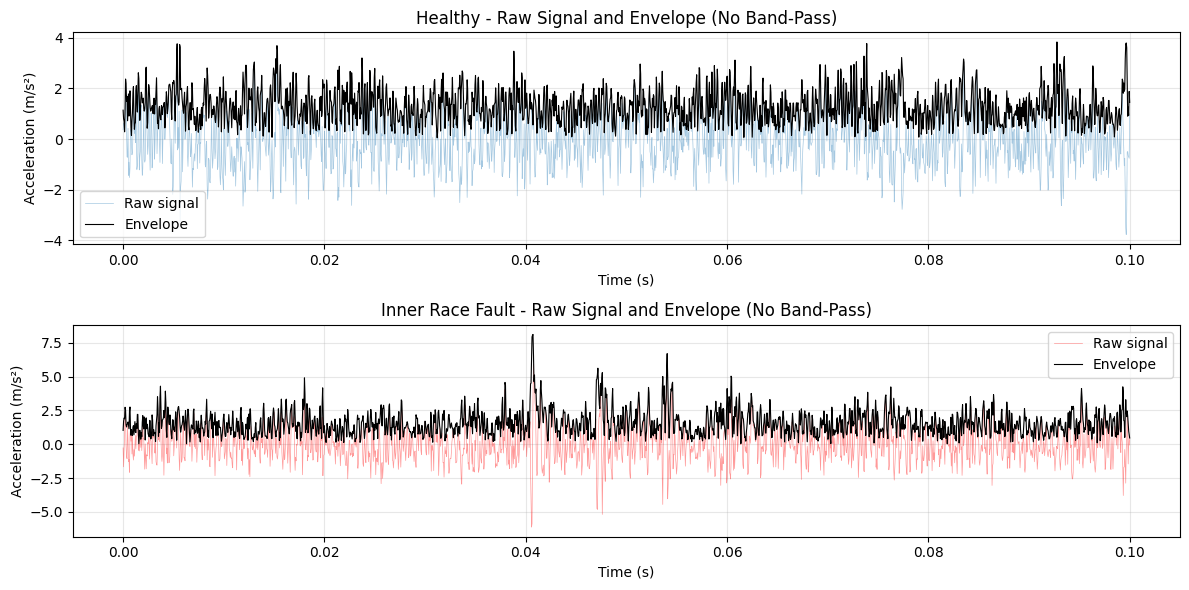

In [15]:
# Compute envelope spectrum (no band-pass filter)
freq_env_h, env_spec_h, env_h, _ = envelope_spectrum(data_h['acc_m_s2'], data_h['fs_acc'], bandpass=None)
freq_env_ir, env_spec_ir, env_ir, _ = envelope_spectrum(data_ir['acc_m_s2'], data_ir['fs_acc'], bandpass=None)

# Plot envelope time series (zoomed)
zoom_duration = 0.1  # seconds
idx_h = np.where(data_h['time_acc'] <= zoom_duration)[0]
idx_ir = np.where(data_ir['time_acc'] <= zoom_duration)[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Healthy: raw signal + envelope
axes[0].plot(data_h['time_acc'][idx_h], data_h['acc_m_s2'][idx_h], linewidth=0.5, alpha=0.4, label='Raw signal')
axes[0].plot(data_h['time_acc'][idx_h], env_h[idx_h], linewidth=0.8, color='black', label='Envelope')
axes[0].set_title("Healthy - Raw Signal and Envelope (No Band-Pass)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Acceleration (m/s²)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Inner race fault: raw signal + envelope
axes[1].plot(data_ir['time_acc'][idx_ir], data_ir['acc_m_s2'][idx_ir], linewidth=0.5, alpha=0.4, color='red', label='Raw signal')
axes[1].plot(data_ir['time_acc'][idx_ir], env_ir[idx_ir], linewidth=0.8, color='black', label='Envelope')
axes[1].set_title("Inner Race Fault - Raw Signal and Envelope (No Band-Pass)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Acceleration (m/s²)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

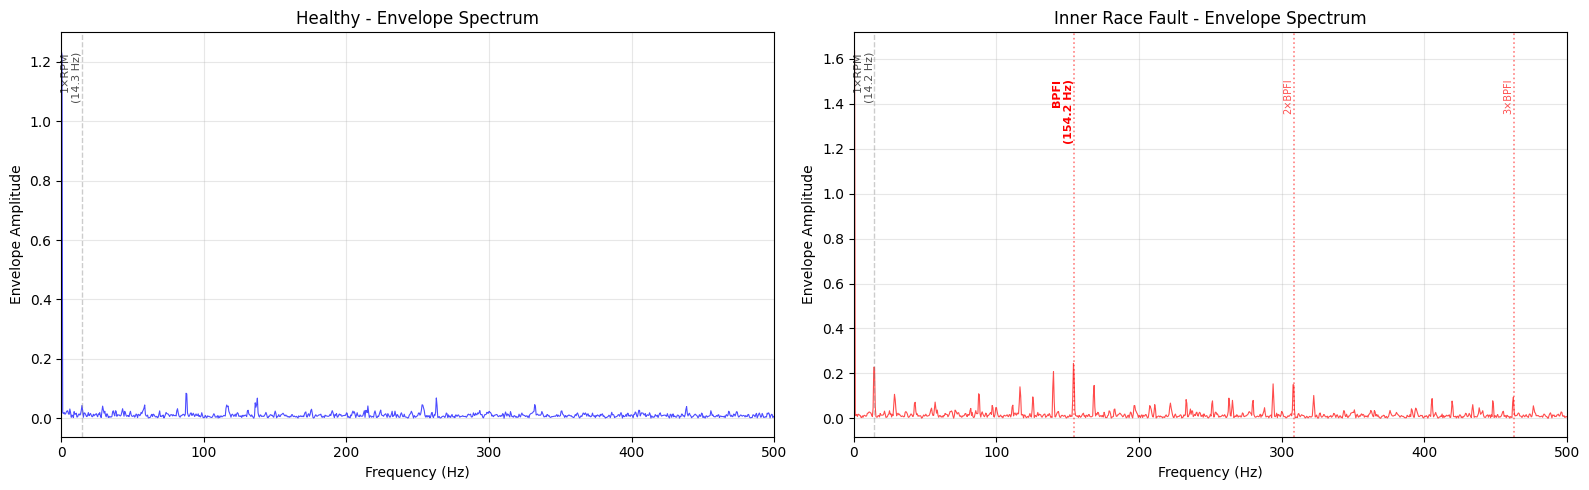

In [16]:
# Plot envelope spectra side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy
axes[0].plot(freq_env_h, env_spec_h, linewidth=0.8, color='blue', alpha=0.7)
axes[0].set_title("Healthy - Envelope Spectrum")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Envelope Amplitude")
axes[0].set_xlim([0, 500])
add_rpm_harmonics(axes[0], data_h['mean_rpm'], max_freq=500, alpha=0.2)
axes[0].grid(True, alpha=0.3)

# Inner Race Fault
axes[1].plot(freq_env_ir, env_spec_ir, linewidth=0.8, color='red', alpha=0.7)
axes[1].set_title("Inner Race Fault - Envelope Spectrum")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Envelope Amplitude")
axes[1].set_xlim([0, 500])
add_rpm_harmonics(axes[1], data_ir['mean_rpm'], max_freq=500, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_ir['mean_rpm'], 'IR', max_freq=500, alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation**: Even without band-pass filtering, we can sometimes see differences between healthy and faulty bearings in the envelope spectrum. However, the envelope can still be "messy" because it includes contributions from all frequency bands, including noise.

---

## 7.3. The Critical Role of Band-Pass Filtering

### Why Filtering is Essential for Envelope Analysis

Envelope analysis without filtering can be "messy" - the envelope includes contributions from **all frequency bands**, including low-frequency noise.

### The Physics: Isolating the Resonance Band 🎯

**1. Targeting the Carrier Frequency $f_c$**

When a bearing fault creates an impact:
- It doesn't generate a single frequency  
- It excites **structural resonances** (natural frequencies of the machine)  
- These resonances act as the **carrier frequency** $f_c$ in our AM signal

Different machine structures have different resonance frequencies, but for many industrial machines they fall in the **1-10 kHz range**.

**2. Improving Signal-to-Noise Ratio (SNR)** 🔇

The raw vibration signal contains unwanted noise:

**Low-Frequency Noise (<100 Hz):**
- Shaft rotational speed (1×RPM)
- Misalignment (2×RPM)  
- Gear mesh frequencies
- **High amplitude** - would dominate the envelope spectrum!

**High-Frequency Noise:**
- Electronic noise
- Other structural vibrations

**The Band-Pass Filter Acts as a Spotlight 🔦:**
- **Removes** low-frequency rotational vibrations (which would mask $f_m$)
- **Removes** high-frequency noise  
- **Keeps** only the resonance band where fault impacts are strongest
- Result: **Dramatically improved SNR**

---

### Mathematical Effect of Filtering

**Before filtering:** 
$$x(t) = x_{\text{low-freq noise}} + x_{\text{AM signal}} + x_{\text{high-freq noise}}$$

**After band-pass (1-3 kHz):** 
$$x_{\text{filtered}}(t) \approx x_{\text{AM signal}}$$

Now the Hilbert transform can cleanly demodulate the amplitude modulation!

---

### Choosing the Filter Band: Why 1-3 kHz?

**Important Note:**  
This is a **starting guess**. The optimal band varies by:
- Machine type and size
- Bearing type
- Mounting configuration
- Structural properties

**Practical Engineering Rule of Thumb:**

For medium-sized rotating machinery (motors, pumps, gearboxes):
- Primary structural resonances: **500 Hz - 5 kHz**
- Sweet spot for many applications: **1-3 kHz**

**Reasoning:**
- **Above 1 kHz:** Far from low-frequency rotational noise  
- **Below 3 kHz:** Still has good signal energy, not too noisy
- **Common resonance zone:** Where impacts excite the structure most effectively

**Advanced Method: The Kurtogram** (discussed in Section 9)  
Automatically finds the optimal band by measuring **spectral kurtosis** - identifying where the signal is most impulsive.

---

## 7.4. Demonstration With Band-Pass Filter: Real Bearing Data

Now let's apply **band-pass filtering** (1-3 kHz) before computing the envelope to isolate high-frequency resonances excited by impacts.

In [18]:
bandpass_range = (1000, 3000)  # 1 kHz to 3 kHz

print(f"Band-pass filter range: {bandpass_range[0]} Hz to {bandpass_range[1]} Hz")
print()

# Compute envelope spectrum with band-pass filter
freq_env_bp_h, env_spec_bp_h, env_bp_h, filt_h = envelope_spectrum(
    data_h['acc_m_s2'], data_h['fs_acc'], bandpass=bandpass_range
)

freq_env_bp_ir, env_spec_bp_ir, env_bp_ir, filt_ir = envelope_spectrum(
    data_ir['acc_m_s2'], data_ir['fs_acc'], bandpass=bandpass_range
)

Band-pass filter range: 1000 Hz to 3000 Hz



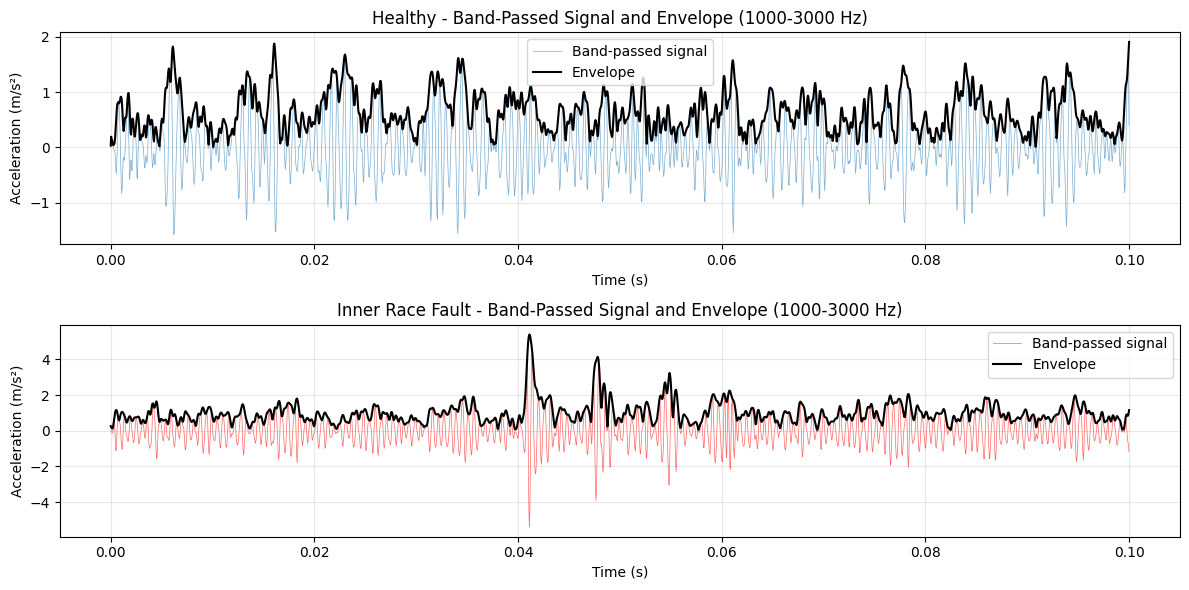

In [19]:
# Plot band-passed signals and envelopes (zoomed)
zoom_duration = 0.1  # seconds
idx_h = np.where(data_h['time_acc'] <= zoom_duration)[0]
idx_ir = np.where(data_ir['time_acc'] <= zoom_duration)[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Healthy: band-passed signal + envelope
axes[0].plot(data_h['time_acc'][idx_h], filt_h[idx_h], linewidth=0.5, alpha=0.6, label='Band-passed signal')
axes[0].plot(data_h['time_acc'][idx_h], env_bp_h[idx_h], linewidth=1.5, color='black', label='Envelope')
axes[0].set_title(f"Healthy - Band-Passed Signal and Envelope ({bandpass_range[0]}-{bandpass_range[1]} Hz)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Acceleration (m/s²)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Inner race fault: band-passed signal + envelope
axes[1].plot(data_ir['time_acc'][idx_ir], filt_ir[idx_ir], linewidth=0.5, alpha=0.6, color='red', label='Band-passed signal')
axes[1].plot(data_ir['time_acc'][idx_ir], env_bp_ir[idx_ir], linewidth=1.5, color='black', label='Envelope')
axes[1].set_title(f"Inner Race Fault - Band-Passed Signal and Envelope ({bandpass_range[0]}-{bandpass_range[1]} Hz)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Acceleration (m/s²)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

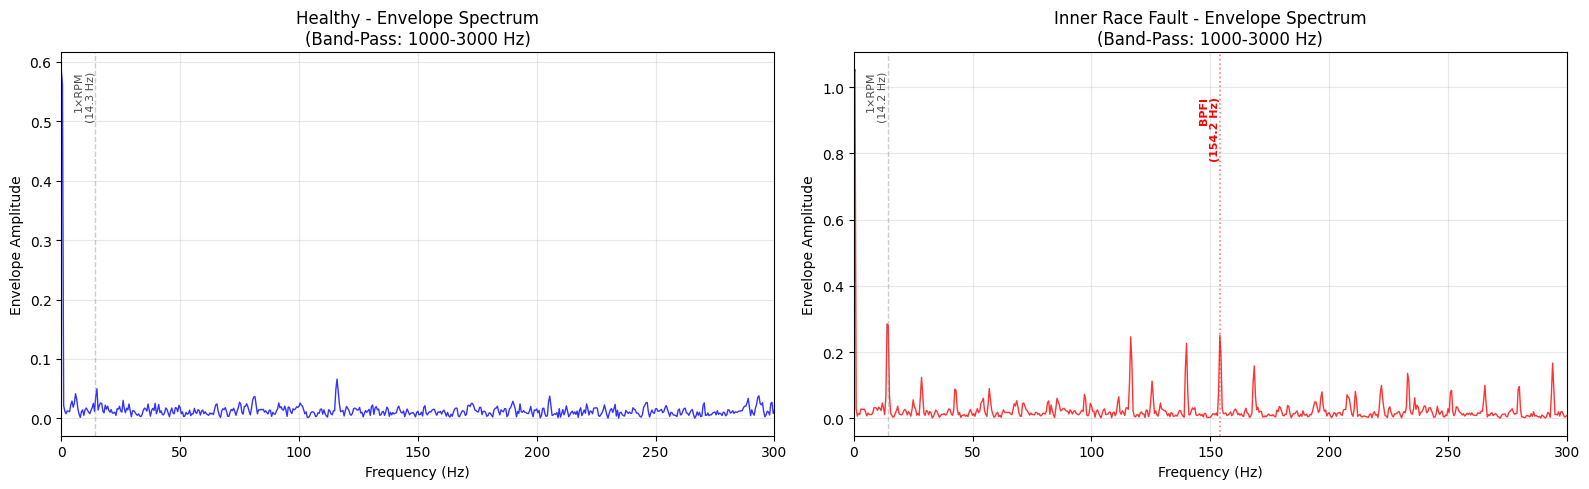

In [20]:
# Plot envelope spectra side-by-side (band-passed)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy
axes[0].plot(freq_env_bp_h, env_spec_bp_h, linewidth=1.0, color='blue', alpha=0.8)
axes[0].set_title(f"Healthy - Envelope Spectrum\n(Band-Pass: {bandpass_range[0]}-{bandpass_range[1]} Hz)")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Envelope Amplitude")
axes[0].set_xlim([0, 300])
add_rpm_harmonics(axes[0], data_h['mean_rpm'], max_freq=300, alpha=0.2)
axes[0].grid(True, alpha=0.3)

# Inner Race Fault
axes[1].plot(freq_env_bp_ir, env_spec_bp_ir, linewidth=1.0, color='red', alpha=0.8)
axes[1].set_title(f"Inner Race Fault - Envelope Spectrum\n(Band-Pass: {bandpass_range[0]}-{bandpass_range[1]} Hz)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Envelope Amplitude")
axes[1].set_xlim([0, 300])
add_rpm_harmonics(axes[1], data_ir['mean_rpm'], max_freq=300, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_ir['mean_rpm'], 'IR', max_freq=300, alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation**: With band-pass filtering, the envelope spectrum becomes **cleaner** and fault-related peaks are more prominent. The inner race fault shows distinct peaks at characteristic fault frequencies that are not present (or much weaker) in the healthy bearing.

These peaks correspond to:

- **Ball Pass Frequency of Inner Race (BPFI)**: The rate at which rolling elements pass over the inner race fault
- **Harmonics** of the fault frequency
- **Sidebands** due to modulation effects

---

---

## 8. Comparative Analysis at 877 rpm: FFT vs Envelope Spectrum

In this section, we systematically compare **three fault types** (Inner Race, Outer Race, Roller) against a healthy bearing at 877 rpm.

For each fault type, we show:
1. **FFT Analysis** - Standard frequency domain analysis
2. **Envelope Analysis** - Advanced demodulation technique

This side-by-side comparison demonstrates why envelope analysis is superior for bearing diagnostics.

**Why 877 rpm?**
- Stronger impact forces → better fault signatures
- Higher fault frequencies → better separation from low-frequency noise
- Improved signal-to-noise ratio overall

### 8.1. Inner Race Fault

**Expected Fault Frequency:** BPFI = 10.824 × (854.9/60) ≈ **154.3 Hz** (using measured mean RPM)

#### 8.1.1. FFT Analysis

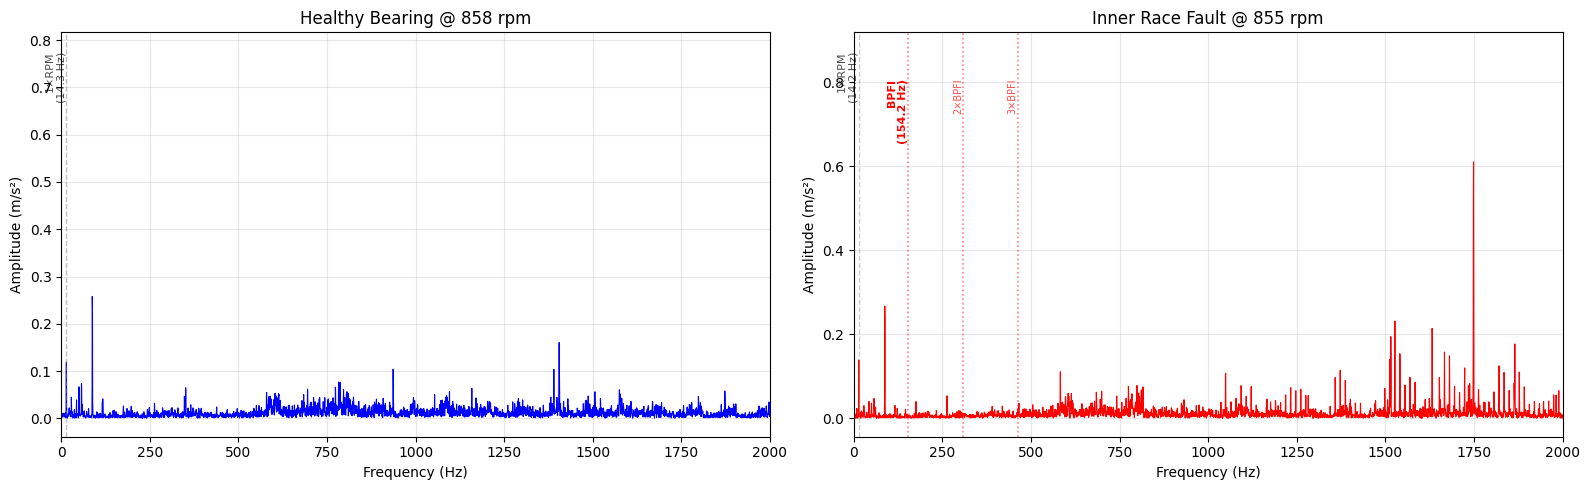

In [22]:
# Load data at 877 rpm
data_h_877 = load_sample('H_877rpm_sample.mat')
data_ir_877 = load_sample('IR_877rpm_sample.mat')

# Compute FFT spectra
freq_h_877, amp_h_877 = compute_spectrum(data_h_877['acc_m_s2'], data_h_877['fs_acc'])
freq_ir_877, amp_ir_877 = compute_spectrum(data_ir_877['acc_m_s2'], data_ir_877['fs_acc'])

# Plot FFT comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy 877 rpm
axes[0].plot(freq_h_877, amp_h_877, linewidth=0.8, color='blue')
axes[0].set_xlim(0, 2000)
add_rpm_harmonics(axes[0], data_h_877['mean_rpm'], max_freq=2000)
axes[0].set_title(f"Healthy Bearing @ {data_h_877['mean_rpm']:.0f} rpm")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Amplitude (m/s²)")
axes[0].grid(True, alpha=0.3)

# Inner Race 877 rpm
axes[1].plot(freq_ir_877, amp_ir_877, linewidth=0.8, color='red')
axes[1].set_xlim(0, 2000)
add_rpm_harmonics(axes[1], data_ir_877['mean_rpm'], max_freq=2000, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_ir_877['mean_rpm'], 'IR', max_freq=2000)
axes[1].set_title(f"Inner Race Fault @ {data_ir_877['mean_rpm']:.0f} rpm")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude (m/s²)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 8.1.2. Envelope Analysis

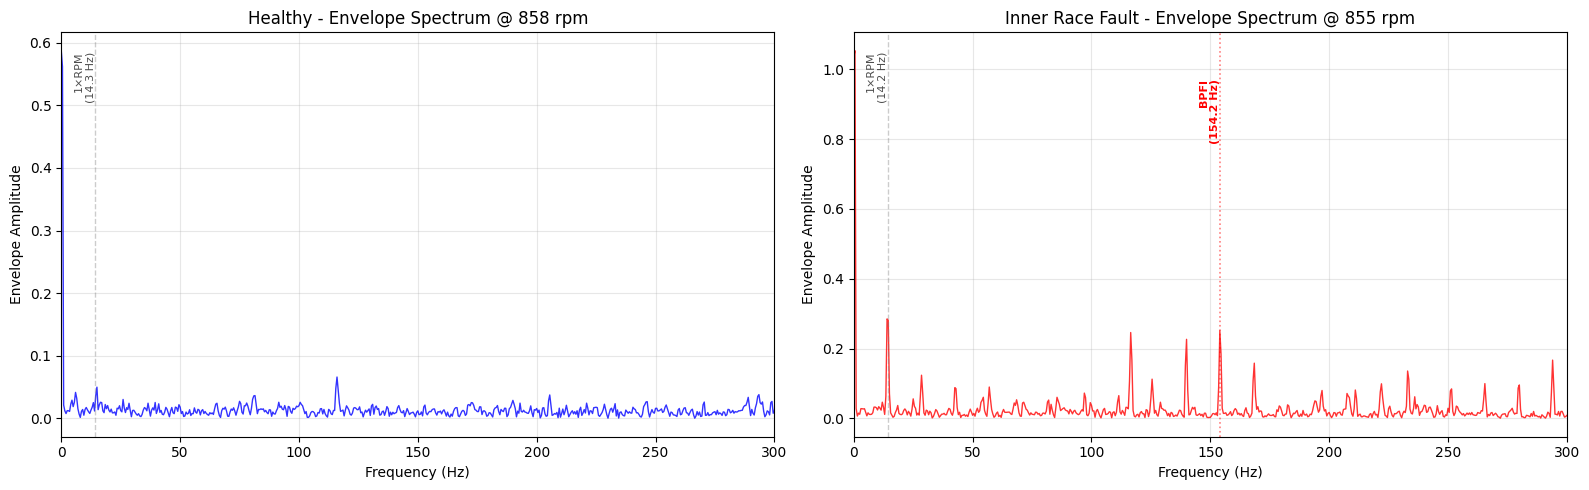

In [23]:
# Compute envelope spectra for Healthy and Inner Race at 877 rpm
freq_env_h_877, env_spec_h_877, _, _ = envelope_spectrum(
    data_h_877['acc_m_s2'], data_h_877['fs_acc'], bandpass=bandpass_range
)
freq_env_ir_877, env_spec_ir_877, _, _ = envelope_spectrum(
    data_ir_877['acc_m_s2'], data_ir_877['fs_acc'], bandpass=bandpass_range
)

# Plot envelope spectra side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy
axes[0].plot(freq_env_h_877, env_spec_h_877, linewidth=1.0, color='blue', alpha=0.8)
axes[0].set_title(f"Healthy - Envelope Spectrum @ {data_h_877['mean_rpm']:.0f} rpm")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Envelope Amplitude")
axes[0].set_xlim([0, 300])
add_rpm_harmonics(axes[0], data_h_877['mean_rpm'], max_freq=300, alpha=0.2)
axes[0].grid(True, alpha=0.3)

# Inner Race Fault
axes[1].plot(freq_env_ir_877, env_spec_ir_877, linewidth=1.0, color='red', alpha=0.8)
axes[1].set_title(f"Inner Race Fault - Envelope Spectrum @ {data_ir_877['mean_rpm']:.0f} rpm")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Envelope Amplitude")
axes[1].set_xlim([0, 300])
add_rpm_harmonics(axes[1], data_ir_877['mean_rpm'], max_freq=300, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_ir_877['mean_rpm'], 'IR', max_freq=300, alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2. Outer Race Fault

**Expected Fault Frequency:** BPFO = 8.176 × (858.9/60) ≈ **117.1 Hz** (using measured mean RPM)

#### 8.2.1. FFT Analysis

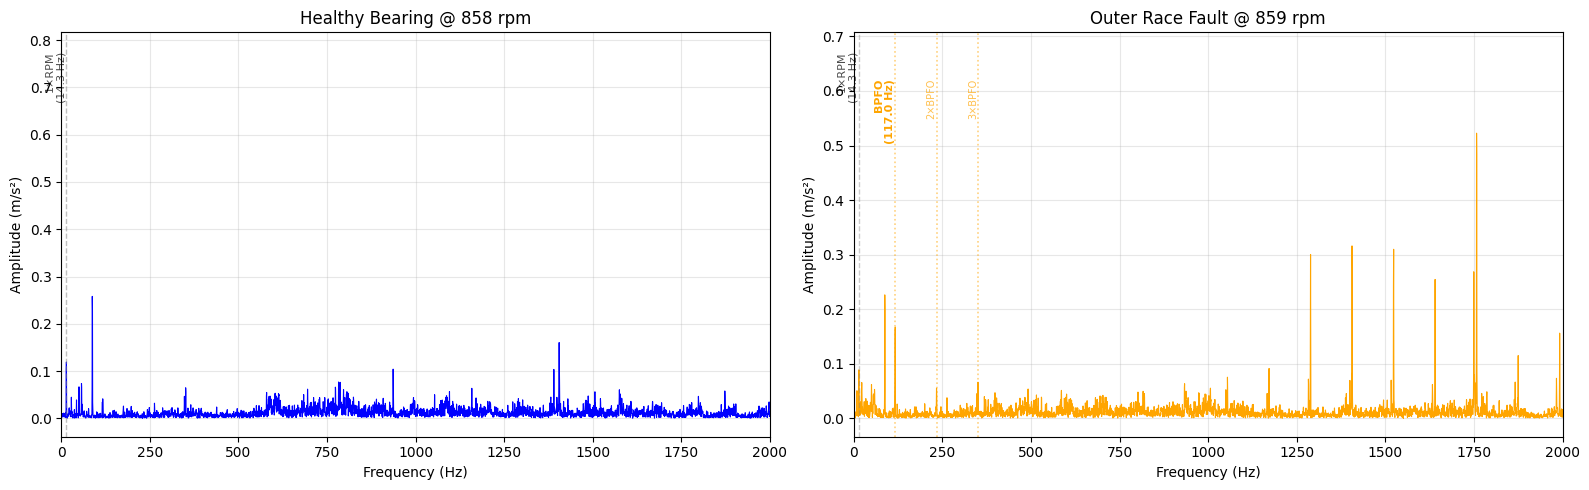

In [24]:
# Load Outer Race fault data at 877 rpm
data_or_877 = load_sample('OR_877rpm_sample.mat')

# Compute FFT spectra
freq_or_877, amp_or_877 = compute_spectrum(data_or_877['acc_m_s2'], data_or_877['fs_acc'])

# Plot FFT comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy 877 rpm
axes[0].plot(freq_h_877, amp_h_877, linewidth=0.8, color='blue')
axes[0].set_xlim(0, 2000)
add_rpm_harmonics(axes[0], data_h_877['mean_rpm'], max_freq=2000)
axes[0].set_title(f"Healthy Bearing @ {data_h_877['mean_rpm']:.0f} rpm")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Amplitude (m/s²)")
axes[0].grid(True, alpha=0.3)

# Outer Race 877 rpm
axes[1].plot(freq_or_877, amp_or_877, linewidth=0.8, color='orange')
axes[1].set_xlim(0, 2000)
add_rpm_harmonics(axes[1], data_or_877['mean_rpm'], max_freq=2000, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_or_877['mean_rpm'], 'OR', max_freq=2000, color='orange')
axes[1].set_title(f"Outer Race Fault @ {data_or_877['mean_rpm']:.0f} rpm")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude (m/s²)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 8.2.2. Envelope Analysis

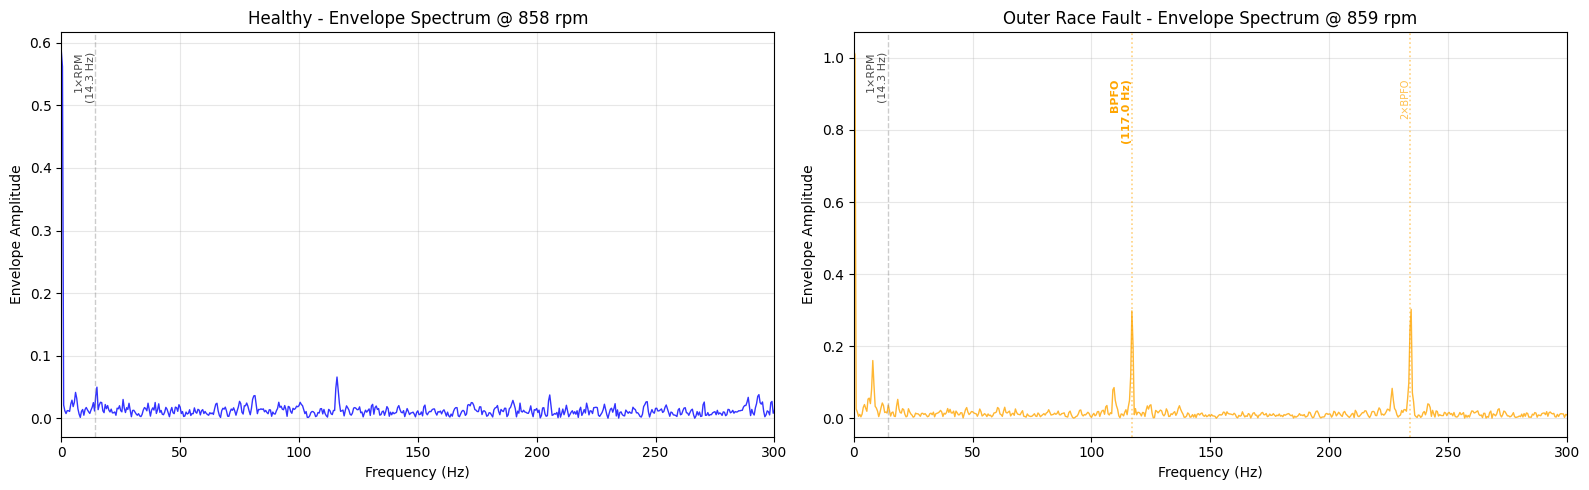

In [25]:
# Compute envelope spectra for Outer Race at 877 rpm
freq_env_or_877, env_spec_or_877, _, _ = envelope_spectrum(
    data_or_877['acc_m_s2'], data_or_877['fs_acc'], bandpass=bandpass_range
)

# Plot envelope spectra side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy
axes[0].plot(freq_env_h_877, env_spec_h_877, linewidth=1.0, color='blue', alpha=0.8)
axes[0].set_title(f"Healthy - Envelope Spectrum @ {data_h_877['mean_rpm']:.0f} rpm")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Envelope Amplitude")
axes[0].set_xlim([0, 300])
add_rpm_harmonics(axes[0], data_h_877['mean_rpm'], max_freq=300, alpha=0.2)
axes[0].grid(True, alpha=0.3)

# Outer Race Fault
axes[1].plot(freq_env_or_877, env_spec_or_877, linewidth=1.0, color='orange', alpha=0.8)
axes[1].set_title(f"Outer Race Fault - Envelope Spectrum @ {data_or_877['mean_rpm']:.0f} rpm")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Envelope Amplitude")
axes[1].set_xlim([0, 300])
add_rpm_harmonics(axes[1], data_or_877['mean_rpm'], max_freq=300, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_or_877['mean_rpm'], 'OR', max_freq=300, alpha=0.5, color='orange')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.3. Roller Fault

**Expected Fault Frequency:** 2×BSF = 2 × 3.464 × (858.1/60) ≈ **99.1 Hz** (using measured mean RPM)

#### 8.3.1. FFT Analysis

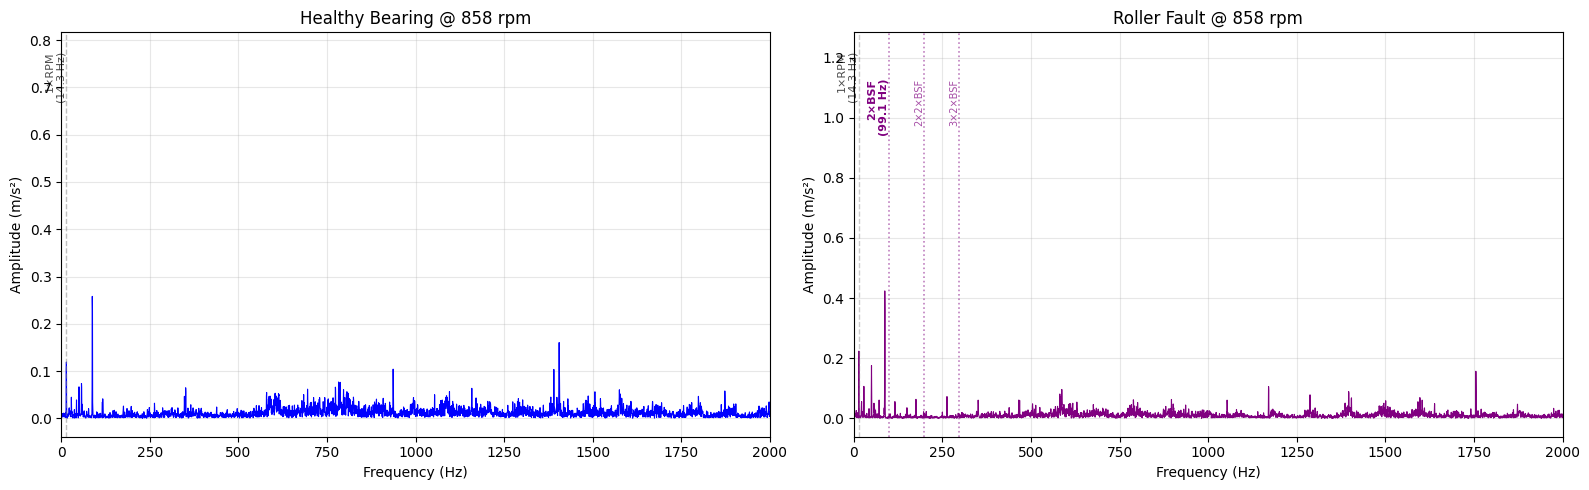

In [26]:
# Load Roller fault data at 877 rpm
data_roller_877 = load_sample('Roller_877rpm_sample.mat')

# Compute FFT spectra
freq_roller_877, amp_roller_877 = compute_spectrum(data_roller_877['acc_m_s2'], data_roller_877['fs_acc'])

# Plot FFT comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy 877 rpm
axes[0].plot(freq_h_877, amp_h_877, linewidth=0.8, color='blue')
axes[0].set_xlim(0, 2000)
add_rpm_harmonics(axes[0], data_h_877['mean_rpm'], max_freq=2000)
axes[0].set_title(f"Healthy Bearing @ {data_h_877['mean_rpm']:.0f} rpm")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Amplitude (m/s²)")
axes[0].grid(True, alpha=0.3)

# Roller 877 rpm
axes[1].plot(freq_roller_877, amp_roller_877, linewidth=0.8, color='purple')
axes[1].set_xlim(0, 2000)
add_rpm_harmonics(axes[1], data_roller_877['mean_rpm'], max_freq=2000, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_roller_877['mean_rpm'], 'Roller', max_freq=2000, color='purple')
axes[1].set_title(f"Roller Fault @ {data_roller_877['mean_rpm']:.0f} rpm")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude (m/s²)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 8.3.2. Envelope Analysis

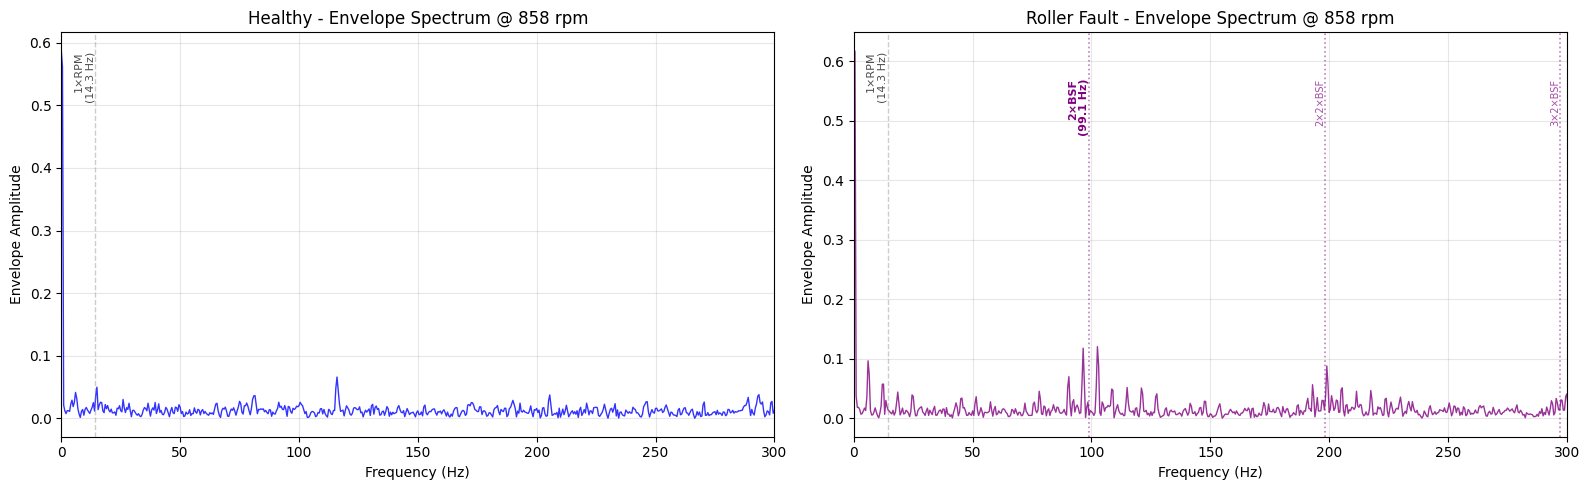

In [27]:
# Compute envelope spectra for Roller at 877 rpm
freq_env_roller_877, env_spec_roller_877, _, _ = envelope_spectrum(
    data_roller_877['acc_m_s2'], data_roller_877['fs_acc'], bandpass=bandpass_range
)

# Plot envelope spectra side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy
axes[0].plot(freq_env_h_877, env_spec_h_877, linewidth=1.0, color='blue', alpha=0.8)
axes[0].set_title(f"Healthy - Envelope Spectrum @ {data_h_877['mean_rpm']:.0f} rpm")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Envelope Amplitude")
axes[0].set_xlim([0, 300])
add_rpm_harmonics(axes[0], data_h_877['mean_rpm'], max_freq=300, alpha=0.2)
axes[0].grid(True, alpha=0.3)

# Roller Fault
axes[1].plot(freq_env_roller_877, env_spec_roller_877, linewidth=1.0, color='purple', alpha=0.8)
axes[1].set_title(f"Roller Fault - Envelope Spectrum @ {data_roller_877['mean_rpm']:.0f} rpm")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Envelope Amplitude")
axes[1].set_xlim([0, 300])
add_rpm_harmonics(axes[1], data_roller_877['mean_rpm'], max_freq=300, alpha=0.2)
add_bearing_fault_frequencies(axes[1], data_roller_877['mean_rpm'], 'Roller', max_freq=300, alpha=0.5, color='purple')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 8.4. Summary: FFT vs Envelope Analysis

### Comparison of Diagnostic Techniques

| Aspect | **FFT Analysis** | **Envelope Analysis** |
|--------|------------------|----------------------|
| **Fault Visibility** | Low to Medium | **Very High** |
| **Noise Level** | High | **Low** |
| **Diagnostic Confidence** | Difficult | **Clear & Unambiguous** |
| **Frequency Resolution** | Good | **Excellent for fault frequencies** |
| **Implementation** | Simple | Requires band-pass selection |

### Key Fault Frequencies at Nominal 877 rpm (Measured Mean ≈ 855–859 rpm)

**Note:** All frequencies below are computed using the **measured mean RPM** from the tachometer, not the nominal 877 RPM. Each test condition has a slightly different mean RPM.

- **Shaft frequency**: ≈ 858 rpm ÷ 60 ≈ **14.3 Hz**
- **Inner Race (BPFI)**: 10.824 × 14.2 Hz ≈ **154.3 Hz** (mean RPM ≈ 855)
- **Outer Race (BPFO)**: 8.176 × 14.3 Hz ≈ **117.1 Hz** (mean RPM ≈ 859)
- **Roller (2×BSF)**: 2 × 3.464 × 14.3 Hz ≈ **99.1 Hz** (mean RPM ≈ 858)

### What You Observed

**FFT Analysis:**
- Fault peaks are present but often buried in noise and structural resonances
- Multiple overlapping harmonics create complex spectra
- Difficult to distinguish fault types with certainty
- Background vibrations dominate the spectrum

**Envelope Analysis:**
- **Inner Race**: Unmistakable peak at ≈154 Hz (BPFI) with clear harmonics
- **Outer Race**: Dominant peak at ≈117 Hz (BPFO), distinct from IR
- **Roller**: Clear signature at ≈99 Hz (2×BSF)
- **Healthy**: Minimal energy at fault frequencies, only shaft harmonics visible

### Why Envelope Analysis Works Better

1. **Band-pass filtering** (1-3 kHz) isolates structural resonances excited by impacts
2. **Hilbert transform** extracts amplitude modulation caused by periodic faults
3. **Demodulation** reveals low-frequency fault patterns hidden in high-frequency carriers
4. **Noise rejection** - only impulsive events (faults) create strong envelope modulation

### Practical Implications

In industrial condition monitoring:
- Envelope analysis is the **gold standard** for rolling-element bearing diagnostics
- Automatic fault detection algorithms rely on envelope peak detection at characteristic frequencies
- Trending envelope amplitude over time enables **predictive maintenance**
- Early fault detection (weeks to months before failure) prevents catastrophic breakdowns

---

## 9. Summary and Wrap-Up

### What We've Learned

In this notebook, you have learned:

**1. Bearing Geometry and Fault Frequencies:**
- Bearing faults create periodic impacts at characteristic frequencies (BPFI, BPFO, BSF, FTF)
- These frequencies are determined by bearing geometry and shaft speed
- Understanding expected frequencies is crucial for diagnosis

**2. Time-Domain Analysis:**
- **Kurtosis** is a useful indicator of impulsive behavior in vibration signals
- Bearings with localized faults exhibit higher kurtosis due to periodic impacts
- Visualization helps identify anomalies in the raw signal

**3. Frequency-Domain Analysis:**
- **FFT of raw signals** can be difficult to interpret because fault energy is spread across many frequencies and mixed with noise
- Standard FFT often fails to clearly reveal bearing fault frequencies
- Background vibrations and structural resonances dominate the spectrum

**4. Envelope Analysis - The Key Technique:**
- **Envelope analysis** using the **Hilbert transform** extracts the amplitude modulation of a signal
- It reveals fault frequencies more clearly by demodulating high-frequency resonances
- The **synthetic signal example** clearly demonstrates how envelope spectrum reveals modulation frequencies hidden in the raw FFT

**5. Band-Pass Filtering:**
- **Band-pass filtering** before envelope computation is essential
- Isolates frequency bands where the fault signal is strong (e.g., structural resonances at 1-3 kHz)
- Enhances the signal-to-noise ratio and makes fault detection much easier
- Removes low-frequency rotational noise and high-frequency electronic noise

**6. Advanced Techniques:**
- **Spectral kurtosis** and the **kurtogram** are advanced tools that automatically find the optimal frequency band for envelope analysis
- While not implemented here, understanding the concept is important for real-world applications
- Industrial software uses these techniques for automated bearing diagnostics

---

### Next Steps

In **Notebook 2**, you will:

- Understand classification metrics in the context of bearing diagnostics
- Evaluate diagnostic system performance using accuracy, precision, recall, and F1-score
- Explore confusion matrices and ROC curves through realistic scenarios
- Learn about the impact of class imbalance on fault detection systems
- Apply metrics to real bearing data without training machine learning models

---

**End of Notebook 1**